In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')

In [2]:
# Load all 10 station files and combine
station_ids = ["05T", "42T", "57T", "58T", "62T", "79T", "82T", "83T", "86T", "87T"]
frames = []
for st in station_ids:
    df = pd.read_csv(f"processed_data/{st}.csv", parse_dates=["date"])
    df["station"] = st
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
print(f"Total: {len(data)} rows, {data['station'].nunique()} stations")
data.head()

Total: 18270 rows, 10 stations


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_direction_10m_dominant,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station
0,2021-01-01,12.8,22.1,0.0,49,9.5,1014.3,56,20.0,05T
1,2021-01-02,14.9,22.1,0.0,10,6.5,1013.5,64,25.0,05T
2,2021-01-03,16.2,23.5,0.0,17,7.8,1012.1,65,37.0,05T
3,2021-01-04,17.8,25.0,0.0,24,7.6,1011.8,65,31.0,05T
4,2021-01-05,19.3,25.5,0.0,21,5.9,1011.8,69,31.0,05T


In [3]:
data.info()
print("\n--- Missing values ---")
print(data.isnull().sum())
print("\n--- PM2.5 missing per station ---")
print(data.groupby("station")["pm25"].apply(lambda x: x.isnull().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18270 entries, 0 to 18269
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         18270 non-null  datetime64[ns]
 1   dew_point_2m_mean            18270 non-null  float64       
 2   temperature_2m_mean          18270 non-null  float64       
 3   precipitation_sum            18270 non-null  float64       
 4   wind_direction_10m_dominant  18270 non-null  int64         
 5   wind_speed_10m_mean          18270 non-null  float64       
 6   surface_pressure_mean        18270 non-null  float64       
 7   relative_humidity_2m_mean    18270 non-null  int64         
 8   pm25                         17805 non-null  float64       
 9   station                      18270 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 1.4+ MB

--- Missing values ---
date  

In [4]:
data.describe()

,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_direction_10m_dominant,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25
count,18270,18270.000000,18270.000000,18270.000000,18270.000000,18270.000000,18270.000000,18270.000000,17805.000000
mean,2023-07-02 02:22:39.605911040,21.810750,26.700159,6.160071,158.970115,7.587028,997.229611,76.823645,22.080696
min,2021-01-01 00:00:00,0.900000,12.400000,0.000000,0.000000,0.800000,952.600000,35.000000,2.000000
25%,2022-04-01 00:00:00,20.400000,25.600000,0.000000,78.000000,5.000000,989.700000,69.000000,9.300000
50%,2023-07-02 00:00:00,23.300000,26.900000,1.600000,173.000000,6.700000,1003.500000,80.000000,15.000000
75%,2024-10-01 00:00:00,24.200000,28.000000,8.500000,221.000000,9.400000,1007.700000,86.000000,26.000000
max,2025-12-31 00:00:00,26.600000,35.200000,146.600000,360.000000,30.400000,1017.600000,100.000000,374.000000
std,NaN,3.513416,2.361825,9.979387,90.221316,3.723211,14.184989,11.639281,22.698557


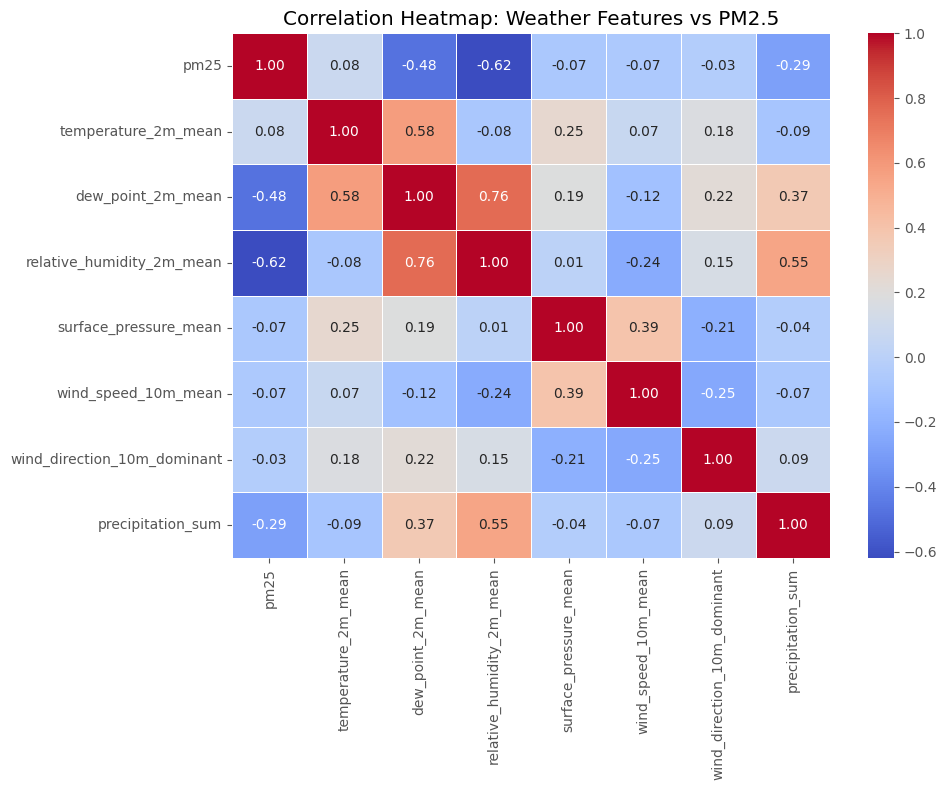

In [5]:
# --- Correlation Heatmap (all stations combined) ---
num_cols = ['pm25', 'temperature_2m_mean', 'dew_point_2m_mean', 'relative_humidity_2m_mean',
            'surface_pressure_mean', 'wind_speed_10m_mean', 'wind_direction_10m_dominant', 'precipitation_sum']

plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Weather Features vs PM2.5')
plt.tight_layout()
plt.show()

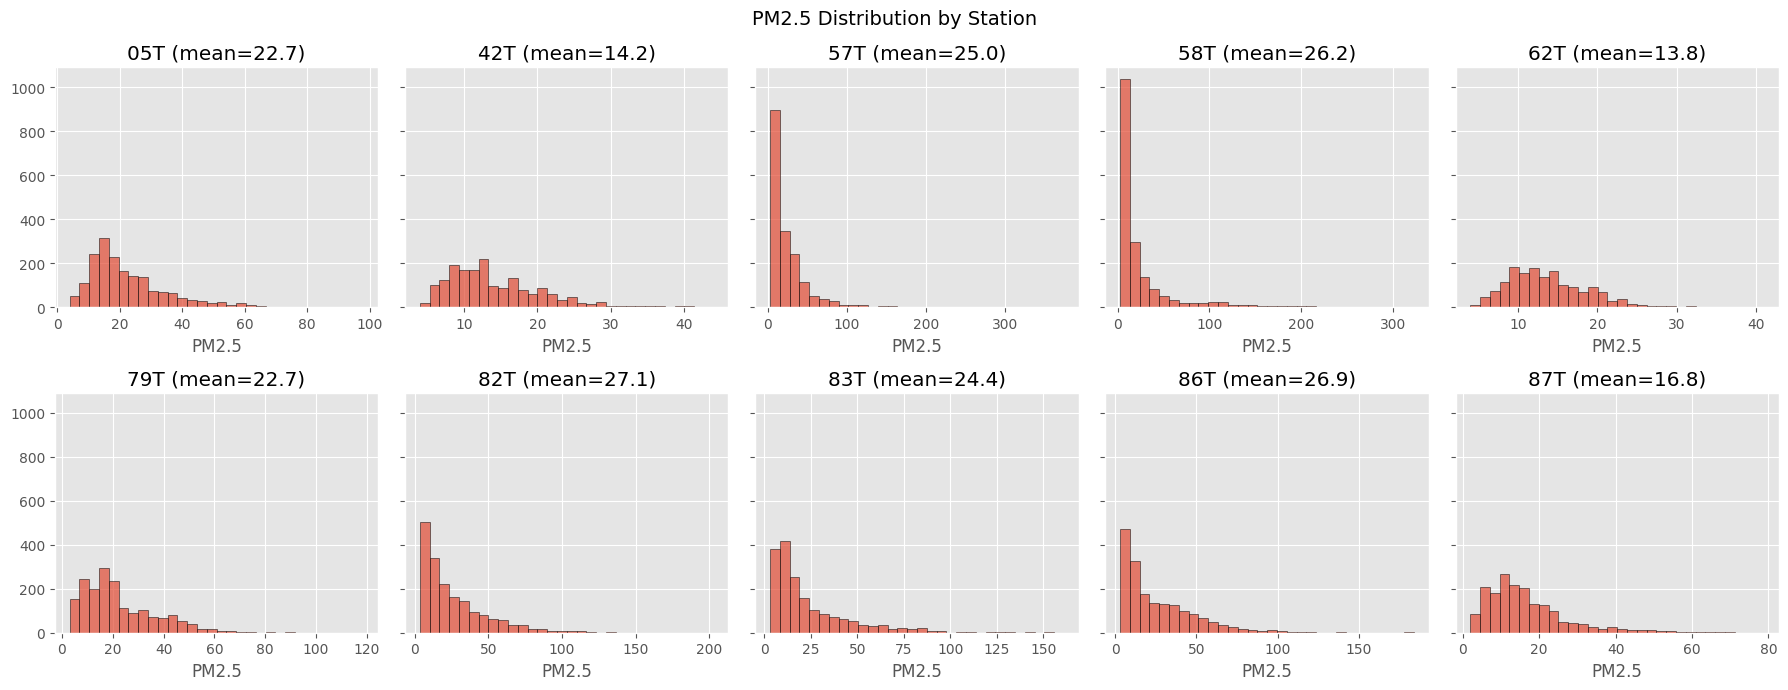

In [6]:
# --- PM2.5 Distribution per station ---
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
for ax, st in zip(axes.flat, station_ids):
    subset = data[data['station'] == st]['pm25'].dropna()
    ax.hist(subset, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'{st} (mean={subset.mean():.1f})')
    ax.set_xlabel('PM2.5')
fig.suptitle('PM2.5 Distribution by Station', fontsize=14)
plt.tight_layout()
plt.show()

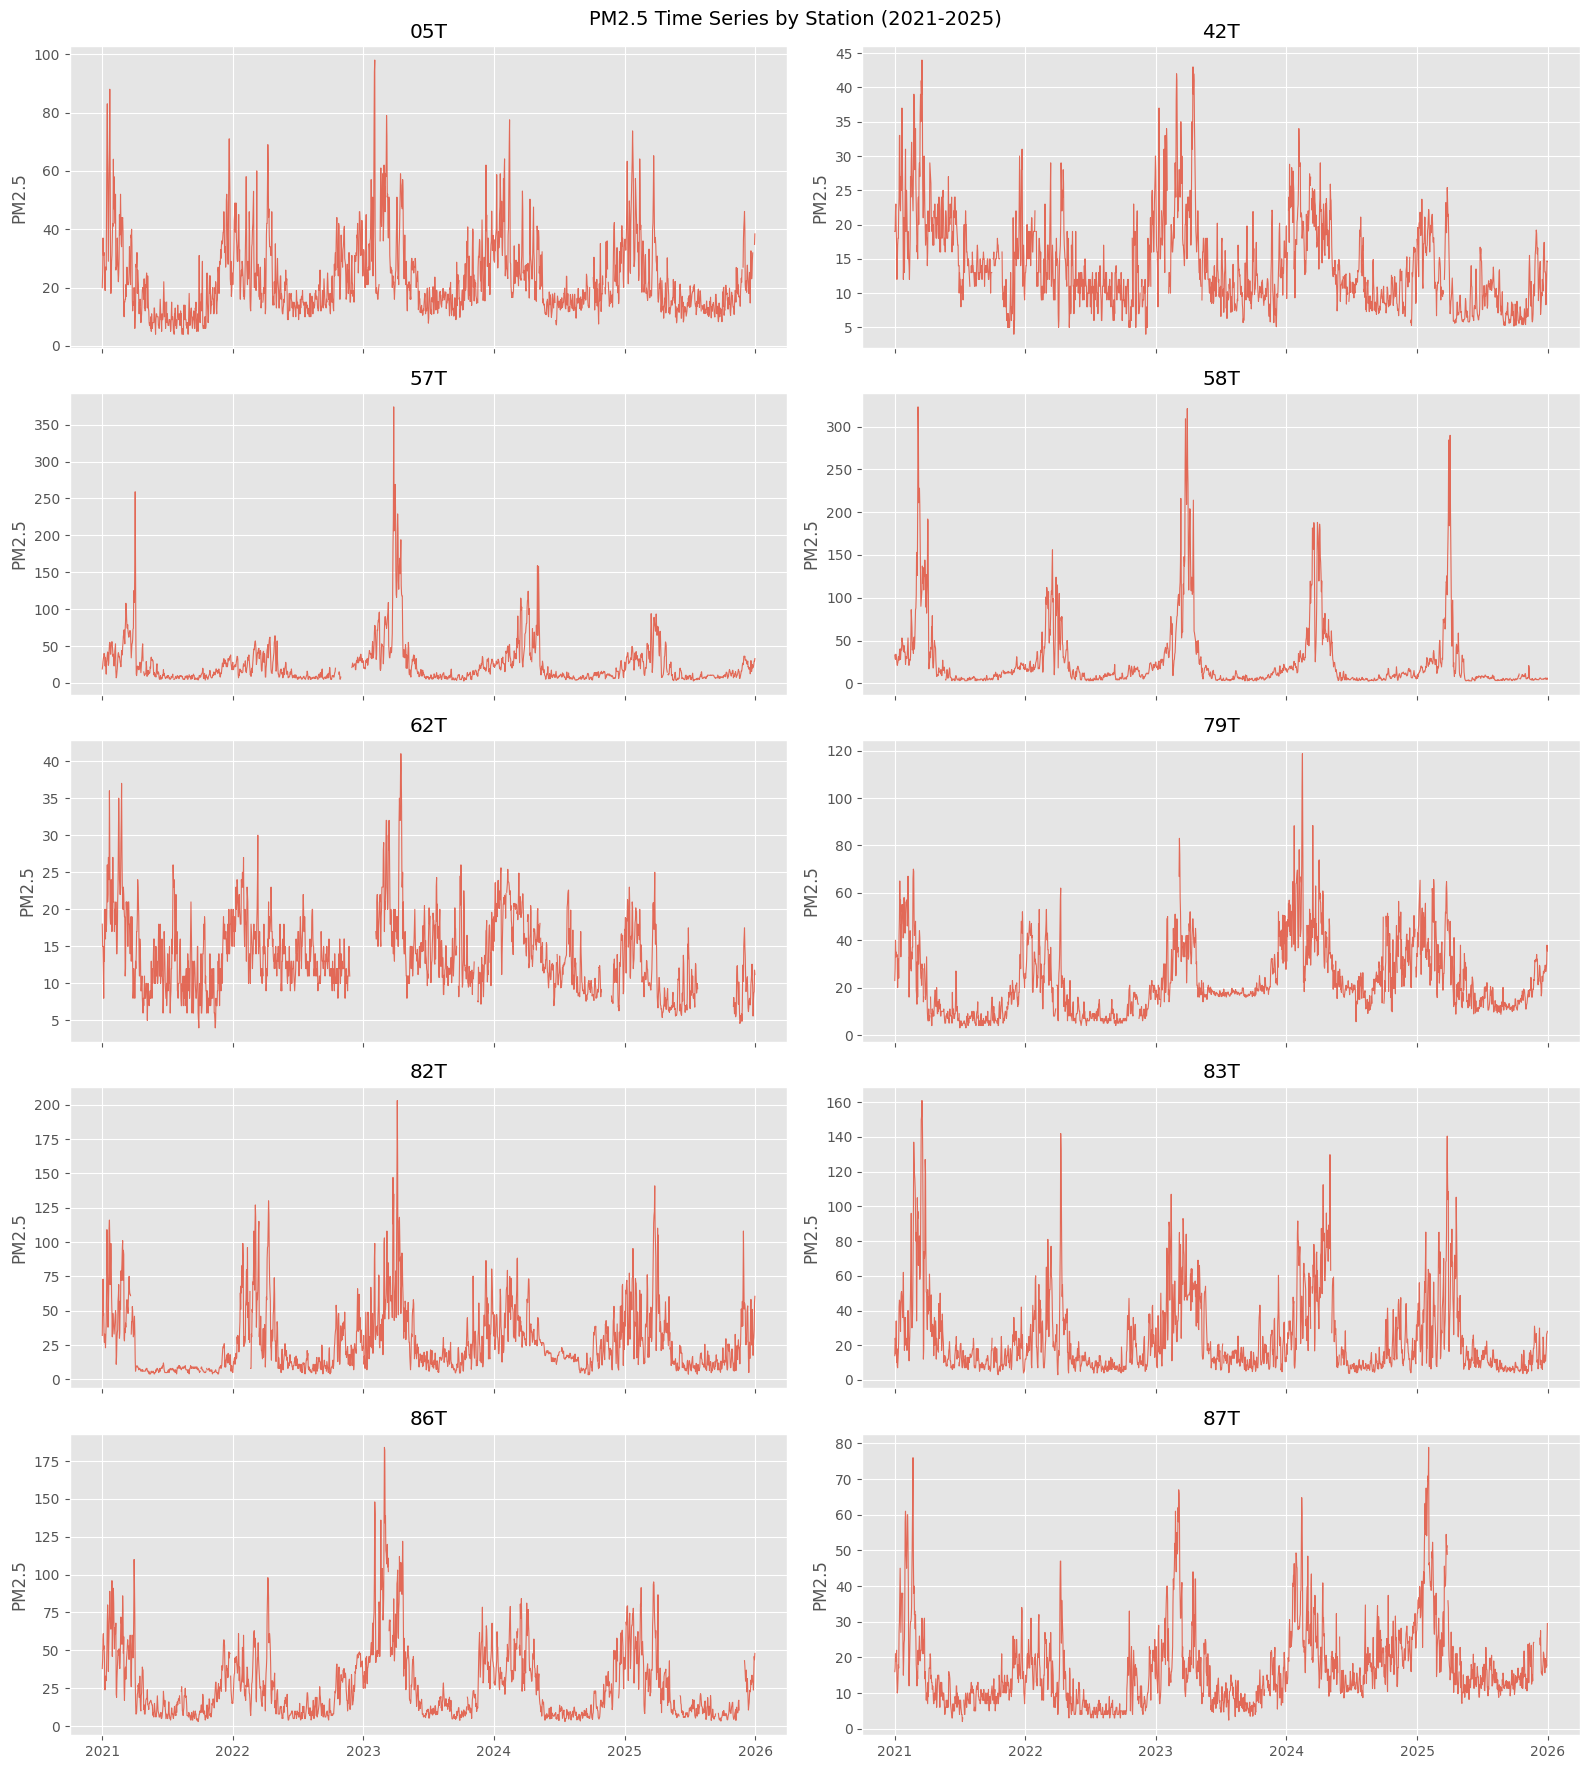

In [7]:
# --- PM2.5 Time Series per station ---
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
for ax, st in zip(axes.flat, station_ids):
    subset = data[data['station'] == st].sort_values('date')
    ax.plot(subset['date'], subset['pm25'], linewidth=0.8, alpha=0.8)
    ax.set_title(f'{st}')
    ax.set_ylabel('PM2.5')
fig.suptitle('PM2.5 Time Series by Station (2021-2025)', fontsize=14)
plt.tight_layout()
plt.show()

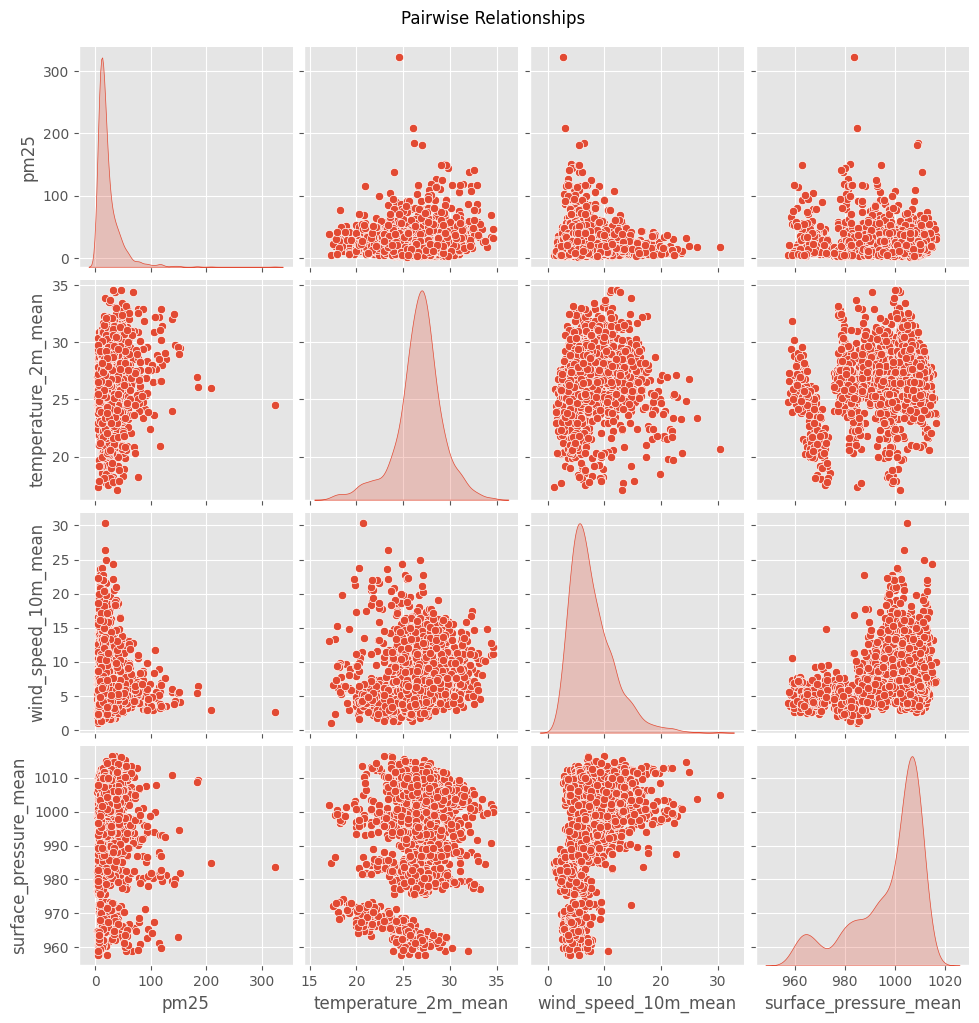

In [8]:
# --- Pairplot: key features vs PM2.5 (sample to avoid slow rendering) ---
sample = data[['pm25', 'temperature_2m_mean', 'wind_speed_10m_mean', 'surface_pressure_mean']].dropna().sample(2000, random_state=42)
sns.pairplot(sample, diag_kind='kde')
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

In [9]:
# --- Data Preparation for Forecasting ---

# 1. Handle missing PM2.5: interpolate within each station
data = data.sort_values(['station', 'date']).reset_index(drop=True)
data['pm25'] = data.groupby('station')['pm25'].transform(lambda x: x.interpolate(method='linear'))

# Check remaining nulls (edges that can't interpolate)
remaining_null = data['pm25'].isnull().sum()
print(f"PM2.5 nulls after interpolation: {remaining_null}")
if remaining_null > 0:
    data['pm25'] = data.groupby('station')['pm25'].transform(lambda x: x.bfill().ffill())
    print(f"PM2.5 nulls after bfill/ffill: {data['pm25'].isnull().sum()}")

PM2.5 nulls after interpolation: 0


In [10]:
# 2. Encode cyclical features: wind direction
data['wind_dir_sin'] = np.sin(2 * np.pi * data['wind_direction_10m_dominant'] / 360)
data['wind_dir_cos'] = np.cos(2 * np.pi * data['wind_direction_10m_dominant'] / 360)
data = data.drop(columns=['wind_direction_10m_dominant'])

In [11]:
# 3. Encode cyclical features: month
data['month'] = data['date'].dt.month
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
data = data.drop(columns=['month'])

In [12]:
# 4. Final dataset overview
print(f"Shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"Null check:\n{data.isnull().sum()}")
data.head(10)

Shape: (18270, 13)
Columns: ['date', 'dew_point_2m_mean', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean', 'surface_pressure_mean', 'relative_humidity_2m_mean', 'pm25', 'station', 'wind_dir_sin', 'wind_dir_cos', 'month_sin', 'month_cos']
Null check:
date                         0
dew_point_2m_mean            0
temperature_2m_mean          0
precipitation_sum            0
wind_speed_10m_mean          0
surface_pressure_mean        0
relative_humidity_2m_mean    0
pm25                         0
station                      0
wind_dir_sin                 0
wind_dir_cos                 0
month_sin                    0
month_cos                    0
dtype: int64


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station,wind_dir_sin,wind_dir_cos,month_sin,month_cos
0,2021-01-01,12.8,22.1,0.0,9.5,1014.3,56,20.0,05T,0.754710,0.656059,0.5,0.866025
1,2021-01-02,14.9,22.1,0.0,6.5,1013.5,64,25.0,05T,0.173648,0.984808,0.5,0.866025
2,2021-01-03,16.2,23.5,0.0,7.8,1012.1,65,37.0,05T,0.292372,0.956305,0.5,0.866025
3,2021-01-04,17.8,25.0,0.0,7.6,1011.8,65,31.0,05T,0.406737,0.913545,0.5,0.866025
4,2021-01-05,19.3,25.5,0.0,5.9,1011.8,69,31.0,05T,0.358368,0.933580,0.5,0.866025
5,2021-01-06,20.1,26.8,0.0,7.5,1010.1,69,32.0,05T,0.819152,0.573576,0.5,0.866025
6,2021-01-07,19.4,26.7,0.0,7.6,1009.3,66,26.0,05T,0.848048,0.529919,0.5,0.866025
7,2021-01-08,18.6,26.7,0.0,14.6,1009.6,62,21.0,05T,0.956305,0.292372,0.5,0.866025
8,2021-01-09,14.7,23.7,0.0,12.6,1011.6,58,19.0,05T,0.939693,0.342020,0.5,0.866025
9,2021-01-10,14.8,23.6,0.0,9.2,1011.6,59,27.0,05T,0.882948,0.469472,0.5,0.866025


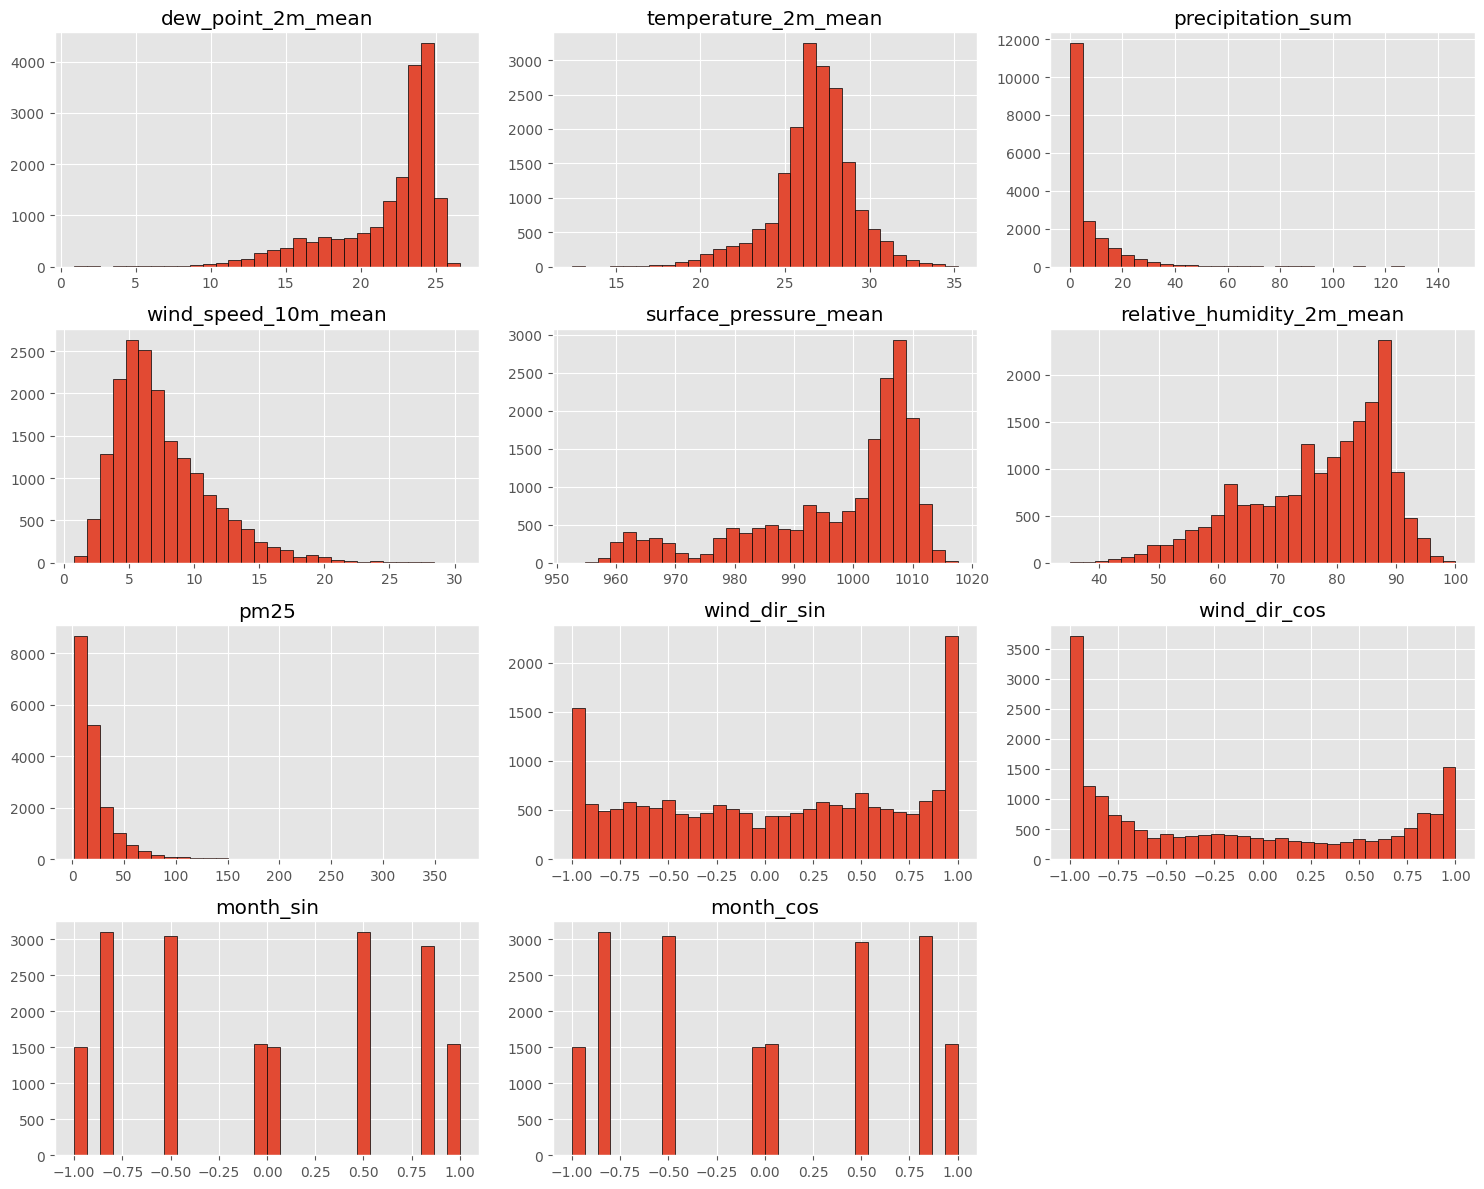

In [13]:
# 5. Histograms of all numeric features
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [14]:
# 6. Export dataset
import os
os.makedirs('dataset', exist_ok=True)
data.to_csv('dataset/dataset.csv', index=False)
print(f"Saved to dataset/dataset.csv ({len(data)} rows)")
data.head()

Saved to dataset/dataset.csv (18270 rows)


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station,wind_dir_sin,wind_dir_cos,month_sin,month_cos
0,2021-01-01,12.8,22.1,0.0,9.5,1014.3,56,20.0,05T,0.754710,0.656059,0.5,0.866025
1,2021-01-02,14.9,22.1,0.0,6.5,1013.5,64,25.0,05T,0.173648,0.984808,0.5,0.866025
2,2021-01-03,16.2,23.5,0.0,7.8,1012.1,65,37.0,05T,0.292372,0.956305,0.5,0.866025
3,2021-01-04,17.8,25.0,0.0,7.6,1011.8,65,31.0,05T,0.406737,0.913545,0.5,0.866025
4,2021-01-05,19.3,25.5,0.0,5.9,1011.8,69,31.0,05T,0.358368,0.933580,0.5,0.866025


C:\Users\kkako\AppData\Local\Temp\ipykernel_76528\3023116892.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')


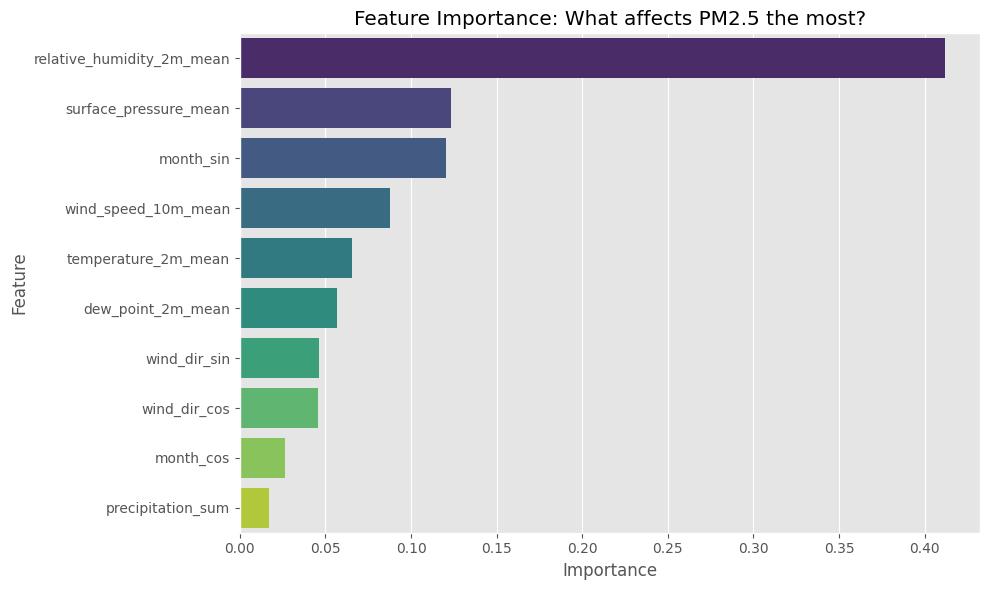

                  Feature  Importance
relative_humidity_2m_mean    0.411827
    surface_pressure_mean    0.123522
                month_sin    0.120146
      wind_speed_10m_mean    0.087512
      temperature_2m_mean    0.065381
        dew_point_2m_mean    0.056441
             wind_dir_sin    0.045968
             wind_dir_cos    0.045548
                month_cos    0.026425
        precipitation_sum    0.017231


In [15]:
# 7. Feature Importance (Random Forest) - quick check
from sklearn.ensemble import RandomForestRegressor

X = data.drop(columns=['pm25', 'date', 'station'])
y = data['pm25']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

fi = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')
plt.title('Feature Importance: What affects PM2.5 the most?')
plt.tight_layout()
plt.show()
print(fi.to_string(index=False))